In [ ]:
import sys
import os
 
# Add project root to Python path
sys.path.append(os.path.abspath(".."))

In [3]:
import pandas as pd

df = pd.read_csv("../data/processed/scaled.csv")
df.head()

,TransactionID,TransactionAmount,TransactionDate,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,TimeSincePrev,AmountBalanceRatio,...,Channel_Branch,Channel_Online,CustomerOccupation_Engineer,CustomerOccupation_Retired,CustomerOccupation_Student,AccountID_freq,DeviceID_freq,IP Address_freq,MerchantID_freq,Location_freq
0,TX000001,-0.971275,2023-04-11 16:29:14,1.423718,-0.552443,-0.206794,-0.000537,2024-11-04 08:08:08,-0.800762,-0.386493,...,False,False,False,False,False,0.394950,0.780834,-1.059021,1.141666,-0.028446
1,TX000002,0.269440,2023-06-27 16:44:19,1.311287,0.305314,-0.206794,2.216472,2024-11-04 08:09:35,-0.076706,-0.338188,...,False,False,False,False,False,0.394950,0.235683,-0.568379,0.168981,0.598373
2,TX000003,-0.586882,2023-07-10 18:16:08,-1.443277,-0.909842,-0.206794,-1.023534,2024-11-04 08:07:04,0.046138,-0.171040,...,False,True,False,False,True,-0.936152,0.235683,0.903547,0.752592,0.284963
3,TX000004,-0.387456,2023-05-05 16:32:11,-1.049768,-1.353017,-0.206794,0.885797,2024-11-04 08:09:06,-0.575097,-0.349611,...,False,True,False,False,True,0.838651,0.780834,1.394189,0.947129,-0.028446
4,TX000005,-0.973468,2023-10-16 17:51:24,-1.049768,1.120184,-0.206794,0.593589,2024-11-04 08:06:39,0.967391,-0.388350,...,False,True,False,False,True,-0.048751,-0.854621,-0.568379,0.947129,0.284963


In [4]:
df = pd.read_csv("../data/processed/scaled.csv")
df.dtypes

TransactionID                   object
TransactionAmount              float64
TransactionDate                 object
CustomerAge                    float64
TransactionDuration            float64
LoginAttempts                  float64
AccountBalance                 float64
PreviousTransactionDate         object
TimeSincePrev                  float64
AmountBalanceRatio             float64
LoginRisk                      float64
TransactionCount               float64
TransactionType_Debit             bool
Channel_Branch                    bool
Channel_Online                    bool
CustomerOccupation_Engineer       bool
CustomerOccupation_Retired        bool
CustomerOccupation_Student        bool
AccountID_freq                 float64
DeviceID_freq                  float64
IP Address_freq                float64
MerchantID_freq                float64
Location_freq                  float64
dtype: object

In [30]:
df = pd.read_csv("../data/processed/scaled.csv")

# Drop non-numeric and unwanted columns
df = df.drop(columns=[
    "TransactionID",
    "CustomerOccupation_Engineer",
    "CustomerOccupation_Retired",
    "TransactionDate",
    "Location_freq",
    "CustomerOccupation_Student",
    "PreviousTransactionDate"
], errors="ignore")

# Keep only numeric columns
df_numeric = df.select_dtypes(include=["int64", "float64", "bool"])

# Convert bool → int
df_numeric = df_numeric.astype(float)


In [23]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(df_numeric)

print("Original shape:", df_numeric.shape)
print("PCA shape:", X_pca.shape)


Original shape: (2512, 16)
PCA shape: (2512, 13)


In [24]:
from src.clustering.kmeans import KMeansClusteringPlus

kmeans = KMeansClusteringPlus(n_clusters=3, init_method="k-means++", n_init=50)
labels = kmeans.fit(X_pca)

metrics = kmeans.evaluate(X_pca)
metrics

{'silhouette_score': 0.12472745140522327,
 'davies_bouldin': 2.216825439963708,
 'calinski_harabasz': 349.8986467635605}

In [25]:
plot_path = kmeans.plot_clusters(X_pca, save_path="../results/kmeans")
plot_path

'../results/kmeans\\cluster_plot_k3.png'

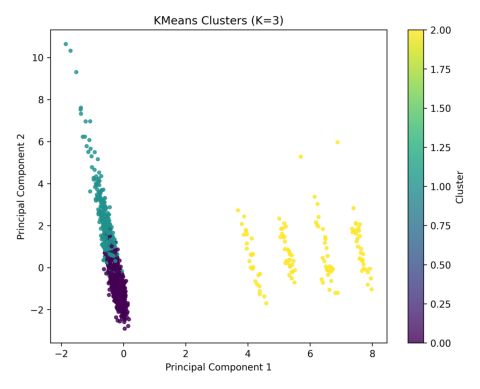

In [26]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread("../results/kmeans/cluster_plot_k3.png")

plt.imshow(img)
plt.axis("off")
plt.show()

In [27]:
import numpy as np

unique, counts = np.unique(kmeans.labels, return_counts=True)
cluster_sizes = dict(zip(unique, counts))

cluster_sizes

{np.int32(0): np.int64(1554),
 np.int32(1): np.int64(836),
 np.int32(2): np.int64(122)}

In [28]:
cluster_variances = {}

for c in np.unique(kmeans.labels):
    points = X_pca[kmeans.labels == c]
    var = np.mean(np.var(points, axis=0))
    cluster_variances[c] = var

cluster_variances


{np.int32(0): np.float64(0.7324430376713491),
 np.int32(1): np.float64(0.8922390794251833),
 np.int32(2): np.float64(0.9678147393158855)}

In [29]:
import pandas as pd
import numpy as np

# Distance from centroid 
centroids = kmeans.model.cluster_centers_
distances = np.linalg.norm(X_pca - centroids[kmeans.labels], axis=1)

# Build anomaly table
anomaly_df = pd.DataFrame({
    "cluster": kmeans.labels,
    "distance": distances
})

# Sort by anomaly score (largest distance = most anomalous)
top_anomalies = anomaly_df.sort_values("distance", ascending=False)

top_anomalies.head(10)


,cluster,distance
2273,1,14.822098
2191,1,13.255470
1459,1,11.612345
934,1,9.721007
311,1,9.510498
1258,1,9.383292
2382,1,9.305557
450,1,8.635251
274,2,8.147143
449,1,7.725671



---

# ✅ **KMeans Anomaly Detection Analysis (K = 3)**

### **Cluster Validity Metrics**
The clustering quality was evaluated using three standard indices:

- **Silhouette Score:** 0.1247  
- **Davies–Bouldin Index:** 2.2168  
- **Calinski–Harabasz Score:** 349.90  

### **Interpretation**
- The **low silhouette score** indicates weak separation between clusters, meaning the dataset has overlapping structures.  
- The **high Davies–Bouldin index** confirms that clusters are not well-separated and have significant internal dispersion.  
- The **moderate Calinski–Harabasz score** suggests that although the clusters exist, they are not strongly compact.

**Conclusion:**  
The dataset is **not naturally well-clustered**, which is typical in anomaly‑detection contexts. KMeans still provides useful structure, but the clusters should be interpreted as *soft groupings* rather than strong natural partitions.

---

## 📌 **Cluster Statistics**

### **Cluster Sizes**
- **Cluster 0:** 1554 points  
- **Cluster 1:** 836 points  
- **Cluster 2:** 122 points  
- **Total:** 2512 points  

A common anomaly‑detection heuristic:  
A cluster is anomalous if its size < **5%** of the dataset.

- 5% threshold = 0.05 × 2512 = **125.6**

Since **Cluster 2 has only 122 points**, it falls below the threshold → **small‑cluster anomaly group**.

---

### **Cluster Variances (Mean Squared Distance to Centroid)**

| Cluster | Variance |
|--------|----------|
| 0      | 0.732    |
| 1      | 0.892    |
| 2      | 0.968    |

- **Cluster 2** has the **highest variance**, meaning it is the least cohesive.  
- This reinforces its role as the **global anomaly cluster**.  
- **Cluster 1** shows moderate variance → more irregular than Cluster 0.  
- **Cluster 0** is the most compact and stable.

---

## 🔍 **Top Distance-Based Anomalies**

| Index | Cluster | Distance |
|-------|---------|----------|
| 2273  | 1       | 14.822   |
| 2191  | 1       | 13.255   |
| 1459  | 1       | 11.612   |
| 934   | 1       | 9.721    |
| 311   | 1       | 9.510    |
| 1258  | 1       | 9.383    |
| 2382  | 1       | 9.305    |
| 450   | 1       | 8.635    |
| 274   | 2       | 8.147    |
| 449   | 1       | 7.725    |

### **Interpretation**
- **Most extreme anomalies come from Cluster 1**, not Cluster 2.  
- These are **local anomalies**: points that deviate strongly from the centroid of a large cluster.  
- Only one top anomaly (index 274) belongs to **Cluster 2**, which is already globally anomalous.

This shows that **distance-based anomaly scoring captures fine-grained deviations** that cluster-size heuristics cannot detect.

---

# ⭐ **Final Interpretation**

### ✔ **Cluster 2 = Global Anomaly Cluster**
- Smallest cluster (122 points < 5% threshold)  
- Highest variance  
- Represents rare, inconsistent, unusual behavior  

### ✔ **Cluster 1 = Local Anomaly Zone**
- Large cluster but contains many extreme outliers  
- High-distance points indicate internal irregularities  
- These are **within-cluster anomalies**  

### ✔ **Cluster 0 = Stable Normal Cluster**
- Largest  
- Most compact  
- No major anomalies  

---

# 🎯 **Summary**
KMeans reveals a **dual anomaly structure**:

### **1. Global anomalies**
- Entire Cluster 2  
- Rare, high-variance, low-density behavior  

### **2. Local anomalies**
- Extreme-distance points inside Cluster 1  
- High deviation from centroid despite belonging to a large cluster  


---
